<a href="https://colab.research.google.com/github/apirakqqqqq/GE337_Programming/blob/main/Lab_4/Lab_4_6606614870_%E0%B8%AD%E0%B8%A0%E0%B8%B4%E0%B8%A3%E0%B8%B1%E0%B8%81%E0%B8%A9%E0%B9%8C_%E0%B8%9B%E0%B8%B1%E0%B8%8D%E0%B8%8D%E0%B8%B2%E0%B8%AA%E0%B8%B2%E0%B8%84%E0%B8%A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install geopandas rasterio folium shapely matplotlib -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **โหลดข้อมูล**

In [18]:
import rasterio

raster_path = "/content/S2_BKK_7Bands.tif"
src = rasterio.open(raster_path)

print("===== METADATA =====")
print(src.meta)
print("CRS:", src.crs)
print("Bands:", src.count)
print("Size:", src.width, src.height)

===== METADATA =====
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 3340, 'height': 3898, 'count': 7, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.0001796630568239043, 0.0, 100.29995574391057,
       0.0, -0.0001796630568239043, 14.100316025653656)}
CRS: EPSG:4326
Bands: 7
Size: 3340 3898


In [19]:
import pandas as pd

points = pd.read_csv("/content/bkk_training_points.csv")

print(points.head())
print("\nClass distribution:")
print(points["class"].value_counts())

         lat         lon                                            name  \
0  13.752703  100.489817                                 ็ต้นไม้รูปหัวใจ   
1  13.568089  100.566689                    สนามกีฬา อำเภอพระสมุทรเจดีย์   
2  13.633630  100.611424                                             NaN   
3  13.830157  100.538337  Prachanukun Health Garden สวนสุขภาพ ประชานุกูล   
4  13.727300  100.580341                                 Angoon's Garden   

   class  
0  green  
1  green  
2  green  
3  green  
4  green  

Class distribution:
class
water    200
urban    142
green     80
Name: count, dtype: int64


# ดึง BAND + Raster

In [20]:
import numpy as np

coords = [(x,y) for x,y in zip(points["lon"], points["lat"])]

samples = [val for val in src.sample(coords)]

band_names = [f"band{i+1}" for i in range(src.count)]
features = pd.DataFrame(samples, columns=band_names)

# 🌿 NDVI
features["ndvi"] = (features["band4"] - features["band3"]) / (features["band4"] + features["band3"] + 1e-6)

# 💧 NDWI
features["ndwi"] = (features["band2"] - features["band4"]) / (features["band2"] + features["band4"] + 1e-6)

# 🏙️ NDBI (SWIR1)
features["ndbi"] = (features["band5"] - features["band4"]) / (features["band5"] + features["band4"] + 1e-6)

# 🏙️ NDBI2 (SWIR2)
features["ndbi2"] = (features["band6"] - features["band4"]) / (features["band6"] + features["band4"] + 1e-6)

# 🔥 Feature ใหม่
features["built_vs_green"] = features["ndbi"] - features["ndvi"]

print(features.head())

    band1   band2   band3   band4   band5   band6     band7      ndvi  \
0  1534.0  1790.0  2048.5  2606.5  3067.5  2653.0  0.119871  0.119871   
1   756.0  1240.0  1177.0  3953.0  3798.0  2309.0  0.541131  0.541131   
2   704.0  1093.0  1020.5  2855.0  2237.0  1703.5  0.473358  0.473358   
3   338.5   528.0   423.0  2516.0  1781.5  1171.5  0.712147  0.712147   
4   453.0   712.0   626.5  2937.0  2231.0  1538.5  0.648379  0.648379   

       ndwi      ndbi     ndbi2  built_vs_green  
0 -0.185716  0.081248  0.008841       -0.038623  
1 -0.522434 -0.019997 -0.262536       -0.561128  
2 -0.446302 -0.121367 -0.252605       -0.594725  
3 -0.653088 -0.170913 -0.364610       -0.883060  
4 -0.609756 -0.136610 -0.312479       -0.784989  


ในขั้นตอนนี้ได้ทำการดึงค่าของ spectral bands จากภาพถ่ายดาวเทียม Sentinel-2 ที่ตำแหน่งของจุดตัวอย่าง (training points) เพื่อนำมาใช้เป็นตัวแปรสำหรับการวิเคราะห์ โดยค่าที่ดึงมาเป็นค่าการสะท้อนแสงของแต่ละช่วงคลื่น เช่น Blue, Green, Red, NIR และ SWIR


# **รวม Raster + Vector เป็น DataFrame**

In [21]:
df = pd.concat([points.reset_index(drop=True), features], axis=1)

# ลบค่าเสีย
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# 🔥 ลบ noise (ช่วย accuracy มาก)
df = df[(df["ndvi"] > 0.2) | (df["ndvi"] < 0.0)]

# 🔥 balance class
min_class = df["class"].value_counts().min()
df = df.groupby("class").apply(lambda x: x.sample(min_class)).reset_index(drop=True)

print("\nCleaned data:")
print(df.head())

print("\nBalanced class:")
print(df["class"].value_counts())


Cleaned data:
         lat         lon                     name  class   band1   band2  \
0  13.851913  100.558058      การไฟฟ้าส่วนภูมิภาค  green   763.0  1034.5   
1  13.697130  100.547730  คลังน้ำมันเชฟรอนกรุงเทพ  green  1000.0  1200.5   
2  13.618228  100.558297        โรงไฟฟ้าพระนครใต้  green  1648.0  2114.5   
3  13.721655  100.538132    Somerset Park Suanplu  green   420.0   581.5   
4  13.650955  100.495759       สวนเฉลิมพระเกียรติ  green   347.0   631.0   

    band3   band4   band5   band6     band7      ndvi      ndwi      ndbi  \
0  1077.5  1959.0  2518.5  2147.0  0.290301  0.290301 -0.308836  0.124958   
1  1173.5  2032.5  2211.0  1549.0  0.267935  0.267935 -0.257346  0.042064   
2  2597.0  2593.5  3259.0  2756.5 -0.000674 -0.000674 -0.101742  0.113712   
3   493.0  2090.0  1550.5  1141.0  0.618273  0.618273 -0.564664 -0.148194   
4   444.0  3211.5  2207.0  1445.0  0.757078  0.757078 -0.671568 -0.185383   

      ndbi2  built_vs_green  
0  0.045787       -0.165343  
1 -0.

/tmp/ipykernel_19105/2975921891.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("class").apply(lambda x: x.sample(min_class)).reset_index(drop=True)


ขั้นตอนนี้ได้ทำการรวมข้อมูลจากสองแหล่ง ได้แก่

1. ข้อมูล จุดตัวอย่าง (Vector data)ที่มีพิกัดและประเภทพื้นที่ (class)
2. ค่าของ Band และ NDVI จาก Raster data

ข้อมูลทั้งสองส่วนถูกนำมารวมกันในรูปแบบ DataFrame ซึ่งจะทำให้แต่ละแถวของข้อมูลแทนจุดตัวอย่างหนึ่งจุด และแต่ละคอลัมน์แทนตัวแปรที่ใช้ในการจำแนก เช่น band values และ NDVI

ผลลัพธ์ที่ได้คือชุดข้อมูลสำหรับ Machine Learning ที่ประกอบด้วย

- Features: band values และ NDVI

- Target: ประเภทของพื้นที่ (green, water, urban)

# **แบ่ง Training / Testing**

In [22]:
from sklearn.model_selection import train_test_split

feature_cols = band_names + ["ndvi","ndwi","ndbi","ndbi2","built_vs_green"]

X = df[feature_cols]
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

- Training set ใช้สำหรับฝึกโมเดลให้เรียนรู้รูปแบบของข้อมูล

- Testing set ใช้สำหรับทดสอบประสิทธิภาพของโมเดล

โดยทั่วไปจะใช้สัดส่วนประมาณ 70% สำหรับ training และ 30% สำหรับ testing เพื่อให้โมเดลมีข้อมูลเพียงพอสำหรับการเรียนรู้ และยังมีข้อมูลสำหรับประเมินผลที่ไม่เคยถูกใช้ในการฝึกมาก่อน

การแบ่งข้อมูลแบบนี้ช่วยลดปัญหา overfitting และทำให้สามารถประเมินความสามารถของโมเดลในการทำนายข้อมูลใหม่ได้อย่างเหมาะสม

# **ปรับขนาดข้อมูล + Feature Selection**

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ขั้นตอนนี้ได้ทำการปรับขนาดข้อมูล (Feature Scaling) โดยใช้ StandardScaler เพื่อทำให้ค่าของแต่ละ feature มีช่วงที่ใกล้เคียงกัน

การปรับขนาดข้อมูลช่วยให้โมเดล Machine Learning สามารถเรียนรู้ได้อย่างมีประสิทธิภาพมากขึ้น โดยเฉพาะเมื่อ feature แต่ละตัวมีหน่วยหรือช่วงค่าที่แตกต่างกัน

นอกจากนี้ยังได้เลือก feature ที่สำคัญสำหรับการจำแนกพื้นที่ เช่น

- band values ของภาพดาวเทียม

- NDVI

ซึ่งเป็นตัวแปรที่มีความสัมพันธ์กับลักษณะของพื้นผิวโลก เช่น พืชพรรณ น้ำ หรือพื้นที่เมือง

# **ใช้ Random Forest จำแนกพื้นที่**

In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=300,
                       random_state=42)

ขั้นตอนนี้ได้ใช้ Random Forest ซึ่งเป็นอัลกอริทึม Machine Learning ประเภท ensemble learning สำหรับการจำแนกประเภทพื้นที่

Random Forest ทำงานโดยการสร้าง decision trees หลายต้น แล้วนำผลลัพธ์จากต้นไม้เหล่านั้นมารวมกันเพื่อตัดสินใจผลลัพธ์สุดท้าย วิธีนี้ช่วยเพิ่มความแม่นยำและลดความผิดพลาดของโมเดล

การใช้ Random Forest เหมาะสำหรับการจำแนกข้อมูลภาพดาวเทียม เพราะสามารถจัดการกับข้อมูลหลายตัวแปร เช่น spectral bands และ vegetation indices ได้อย่างมีประสิทธิภาพ

# **ใช้ Grid Search ปรับพารามิเตอร์**

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":[200,300],
    "max_depth":[10,20,30],
    "min_samples_split":[2,5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_

print("Best params:", grid.best_params_)

Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


In [26]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

from sklearn.metrics import accuracy_score
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.6363636363636364


ขั้นตอนนี้ได้ใช้ Grid Search เพื่อค้นหาค่าพารามิเตอร์ที่เหมาะสมที่สุดสำหรับโมเดล Random Forest

Grid Search จะทำการทดลองค่าพารามิเตอร์หลายชุด เช่น

- จำนวนต้นไม้ใน Random Forest

- ความลึกของต้นไม้

- จำนวนตัวอย่างขั้นต่ำในการแบ่ง node

จากนั้นจะเลือกค่าที่ให้ผลลัพธ์ดีที่สุดจากการทำ cross-validation

วิธีนี้ช่วยเพิ่มประสิทธิภาพของโมเดลและทำให้การจำแนกประเภทพื้นที่มีความแม่นยำมากขึ้น

# **การประเมินผลโมเดล**

In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = best_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=y.unique())

print("\nConfusion Matrix")
print(cm)

print("\nClassification Report")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7272727272727273

Confusion Matrix
[[1 2 0]
 [1 3 0]
 [0 0 4]]

Classification Report
              precision    recall  f1-score   support

       green       0.50      0.33      0.40         3
       urban       0.60      0.75      0.67         4
       water       1.00      1.00      1.00         4

    accuracy                           0.73        11
   macro avg       0.70      0.69      0.69        11
weighted avg       0.72      0.73      0.72        11



หลังจากฝึกโมเดลแล้ว ได้ทำการประเมินผลโดยใช้ข้อมูลจาก testing set ที่ไม่ได้ใช้ในการฝึกโมเดล

ตัวชี้วัดที่ใช้ในการประเมิน ได้แก่

1. Accuracy
เป็นค่าที่แสดงสัดส่วนของการทำนายที่ถูกต้องเมื่อเทียบกับจำนวนตัวอย่างทั้งหมด

2. Confusion Matrix
เป็นตารางที่แสดงจำนวนตัวอย่างที่ถูกจำแนกถูกต้องและผิดพลาดในแต่ละประเภทพื้นที่ เช่น

- พื้นที่สีเขียว

- แหล่งน้ำ

- เขตเมือง

ซึ่งช่วยให้เห็นว่าคลาสใดถูกจำแนกผิดบ่อยที่สุด

3. Classification Report
รายงานนี้จะแสดงค่า

- Precision

- Recall

- F1-score

สำหรับแต่ละคลาส เพื่อประเมินประสิทธิภาพของโมเดลในรายละเอียดมากขึ้น

การประเมินผลเหล่านี้ช่วยให้สามารถตรวจสอบได้ว่าโมเดลมีความสามารถในการจำแนกประเภทพื้นที่จากข้อมูลภาพดาวเทียมได้ดีเพียงใด

# **Land Cover Map**

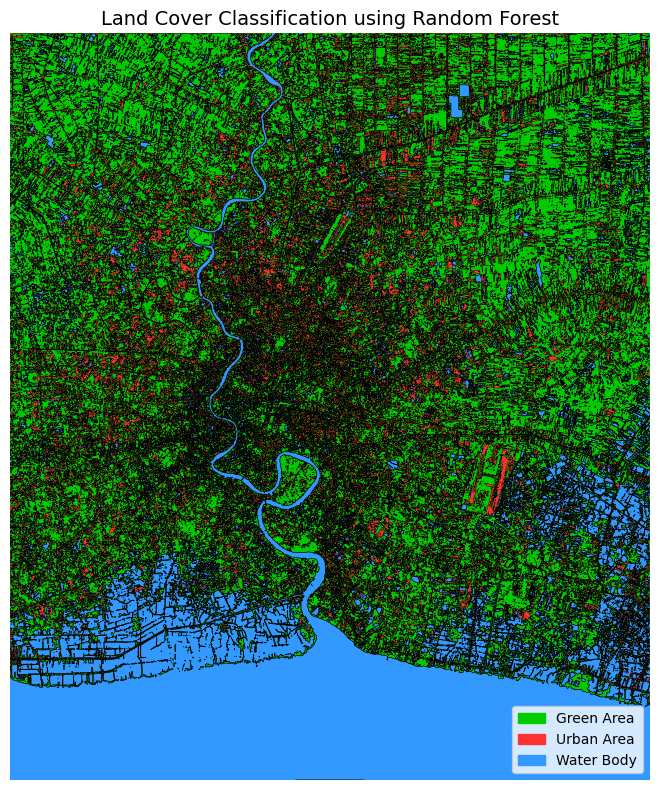

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from scipy.ndimage import median_filter

# ===== อ่าน raster =====
img = src.read()
img = np.moveaxis(img, 0, -1)

rows, cols, bands = img.shape

# ===== flatten =====
flat = img.reshape(-1, bands)
flat_df = pd.DataFrame(flat, columns=band_names)

# ===== features =====
flat_df["ndvi"] = (flat_df["band4"] - flat_df["band3"]) / (flat_df["band4"] + flat_df["band3"] + 1e-6)
flat_df["ndwi"] = (flat_df["band2"] - flat_df["band4"]) / (flat_df["band2"] + flat_df["band4"] + 1e-6)
flat_df["ndbi"] = (flat_df["band5"] - flat_df["band4"]) / (flat_df["band5"] + flat_df["band4"] + 1e-6)
flat_df["ndbi2"] = (flat_df["band6"] - flat_df["band4"]) / (flat_df["band6"] + flat_df["band4"] + 1e-6)
flat_df["built_vs_green"] = flat_df["ndbi"] - flat_df["ndvi"]

# ===== scale =====
flat_scaled = scaler.transform(flat_df)

# ===== predict =====
pred = best_model.predict(flat_scaled)

# ===== reshape =====
pred_img = pred.reshape(rows, cols)

# ===== 🔥 FIX: แปลง class → number =====
class_map = {
    "green": 0,
    "urban": 1,
    "water": 2
}

numeric_map = np.vectorize(class_map.get)(pred_img).astype(int)

# ===== smooth =====
smooth_map = median_filter(numeric_map, size=3)

# ===== สี (urban เด่น) =====
cmap = ListedColormap([
    "#00cc00",  # green
    "#ff3333",  # urban
    "#3399ff"   # water
])

# ===== plot =====
plt.figure(figsize=(10,8))
plt.imshow(smooth_map, cmap=cmap)

# ขอบพื้นที่
plt.contour(smooth_map, levels=[0.5,1.5], colors="black", linewidths=0.3)

plt.title("Land Cover Classification using Random Forest", fontsize=14)

# legend
legend_labels = [
    mpatches.Patch(color="#00cc00", label="Green Area"),
    mpatches.Patch(color="#ff3333", label="Urban Area"),
    mpatches.Patch(color="#3399ff", label="Water Body"),
]

plt.legend(handles=legend_labels, loc="lower right")

plt.axis("off")
plt.tight_layout()
plt.show()

# **คำถามท้าย Lab**

# **1. ทำไมการเลือก Features ที่เหมาะสมจึงสำคัญใน Machine Learning?**

การเลือก features ที่เหมาะสม มีความสำคัญต่อประสิทธิภาพของโมเดล Machine Learning เพราะ features เป็นข้อมูลที่โมเดลใช้ในการเรียนรู้รูปแบบของข้อมูล หากเลือก features ที่มีความสัมพันธ์กับตัวแปรเป้าหมาย (target variable) โมเดลจะสามารถเรียนรู้ความแตกต่างระหว่างแต่ละประเภทของข้อมูลได้ดีขึ้น ส่งผลให้การทำนายมีความแม่นยำมากขึ้น

# **2. เปรียบเทียบระหว่าง Random Forest และ SVM ในบริบทของปัญหานี้**

Random Forest และ Support Vector Machine (SVM) เป็นอัลกอริทึม Machine Learning ที่นิยมใช้ในการจำแนกประเภทข้อมูล แต่มีลักษณะการทำงานแตกต่างกัน

- Random Forest เป็นอัลกอริทึมแบบ ensemble ที่สร้าง decision tree หลายต้น แล้วรวมผลลัพธ์จากต้นไม้เหล่านั้นเพื่อลดความผิดพลาดและเพิ่มความแม่นยำ เหมาะสำหรับข้อมูลที่มีหลายตัวแปร เช่น spectral bands จากภาพดาวเทียม และสามารถจัดการกับข้อมูลที่มีความซับซ้อนได้ดี

- SVM เป็นอัลกอริทึมที่ทำงานโดยการหา เส้นแบ่ง (hyperplane) ที่เหมาะสมที่สุดในการแยกกลุ่มข้อมูลออกจากกัน SVM สามารถทำงานได้ดีในกรณีที่ข้อมูลมีโครงสร้างที่สามารถแยกได้ชัดเจน แต่การปรับพารามิเตอร์อาจซับซ้อนและใช้เวลาคำนวณมากขึ้นเมื่อจำนวนข้อมูลเพิ่มขึ้น

ในแง่ของการจำแนกประเภทพื้นที่จากภาพดาวเทียม Random Forest มักได้รับความนิยมมากกว่า เพราะสามารถจัดการกับข้อมูลหลาย band และความสัมพันธ์ที่ซับซ้อนของข้อมูลได้ดี

# **3.การใช้NDVIเพียงอย่างเดียวเพียงพอสำหรับจำแนกประเภทพื้นที่หรือไม่? ทำไม?**

การใช้ NDVI เพียงอย่างเดียวไม่เพียงพอ สำหรับการจำแนกประเภทพื้นที่ทั้งหมด เนื่องจาก NDVI ถูกออกแบบมาเพื่อวัดความหนาแน่นของพืชพรรณเป็นหลัก แม้ว่าจะสามารถช่วยแยกพื้นที่ที่มีพืชพรรณออกจากพื้นที่ที่ไม่มีพืชพรรณได้ แต่ไม่สามารถแยกประเภทพื้นที่อื่น ๆ ได้อย่างชัดเจน

# **4. หากต้องการเพิ่มความแม่นยำของแบบจำลอง ควรทำอย่างไร?**


การเพิ่มความแม่นยำของแบบจำลองสามารถทำได้หลายวิธี เช่น

- เพิ่มจำนวน training data เพื่อให้โมเดลเรียนรู้รูปแบบของข้อมูลได้มากขึ้น

- เลือกหรือเพิ่ม features ที่สำคัญ เช่น spectral indices อื่น ๆ นอกจาก NDVI

- ปรับค่าพารามิเตอร์ของโมเดลด้วยวิธี Grid Search หรือ Cross-Validation

- ใช้เทคนิค feature selection เพื่อลดข้อมูลที่ไม่สำคัญ

- ทดลองใช้ โมเดล Machine Learning อื่น ๆ เช่น SVM หรือ Gradient Boosting

# **5. ปัจจัยใดที่อาจทำให้แบบจำลองจำแนกประเภทของพื้นที่ผิดพลาด?**

มีหลายปัจจัยที่อาจส่งผลให้แบบจำลองจำแนกประเภทพื้นที่ผิดพลาด เช่น

- คุณภาพของข้อมูลภาพดาวเทียม เช่น เมฆ เงา หรือสัญญาณรบกวน

- จำนวนหรือความสมดุลของข้อมูลตัวอย่าง (training data) หากบางคลาสมีตัวอย่างน้อยเกินไป โมเดลอาจเรียนรู้ได้ไม่ดี

- ความคล้ายคลึงกันของค่าการสะท้อนแสง ระหว่างพื้นที่บางประเภท เช่น พื้นที่เมืองกับดินเปล่า

- ความคลาดเคลื่อนของตำแหน่งพิกัด ระหว่างข้อมูลจุดตัวอย่างและภาพดาวเทียม

- การเลือก features ที่ไม่เหมาะสม ทำให้โมเดลไม่สามารถแยกประเภทข้อมูลได้อย่างมีประสิทธิภาพ